# Content-Based Course Recommendation System

This notebook implements a content-based filtering approach for recommending educational courses based on course metadata and genre classifications. We'll use real course data to develop a system that can suggest relevant courses based on content similarity.

## Setting up the environment

First, let's import the necessary libraries for our recommendation system.

In [30]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# NLP and ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# For later saving our model
import pickle

# Set up paths
data_dir = "data"
course_file = os.path.join(data_dir, "course_genre.csv")
ratings_file = os.path.join(data_dir, "ratings.csv")

## Loading and Exploring the Dataset

We'll use a dataset of courses with genres and ratings information.

In [31]:
# Load the course dataset
courses_df = pd.read_csv(course_file)

# Display the first few rows
courses_df.head()

,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0


In [32]:
# Check the dataset info
courses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   COURSE_ID        307 non-null    object
 1   TITLE            307 non-null    object
 2   Database         307 non-null    int64 
 3   Python           307 non-null    int64 
 4   CloudComputing   307 non-null    int64 
 5   DataAnalysis     307 non-null    int64 
 6   Containers       307 non-null    int64 
 7   MachineLearning  307 non-null    int64 
 8   ComputerVision   307 non-null    int64 
 9   DataScience      307 non-null    int64 
 10  BigData          307 non-null    int64 
 11  Chatbot          307 non-null    int64 
 12  R                307 non-null    int64 
 13  BackendDev       307 non-null    int64 
 14  FrontendDev      307 non-null    int64 
 15  Blockchain       307 non-null    int64 
dtypes: int64(14), object(2)
memory usage: 38.5+ KB


In [33]:
# Check for missing values
courses_df.isnull().sum()

COURSE_ID          0
TITLE              0
Database           0
Python             0
CloudComputing     0
DataAnalysis       0
Containers         0
MachineLearning    0
ComputerVision     0
DataScience        0
BigData            0
Chatbot            0
R                  0
BackendDev         0
FrontendDev        0
Blockchain         0
dtype: int64

In [34]:
# Load and explore the ratings dataset
ratings_df = pd.read_csv(ratings_file)
ratings_df.head()

,user,item,rating
0,1889878,CC0101EN,5
1,1342067,CL0101EN,3
2,1990814,ML0120ENv3,5
3,380098,BD0211EN,5
4,779563,DS0101EN,3


In [35]:
# Basic statistics about ratings
print(f"Total number of ratings: {len(ratings_df)}")
print(f"Number of unique users: {ratings_df['user'].nunique()}")
print(f"Number of unique courses rated: {ratings_df['item'].nunique()}")
print(f"Rating distribution:")
ratings_df['rating'].value_counts().sort_index()

Total number of ratings: 233306
Number of unique users: 33901
Number of unique courses rated: 126
Rating distribution:


rating
3    77866
4    77936
5    77504
Name: count, dtype: int64

## Creating Course Features

We need to create meaningful features from the genre information to enable content-based recommendations.

In [36]:
# Let's look at the genre columns
genre_columns = courses_df.columns[2:]
print(f"Course genre columns: {list(genre_columns)}")

Course genre columns: ['Database', 'Python', 'CloudComputing', 'DataAnalysis', 'Containers', 'MachineLearning', 'ComputerVision', 'DataScience', 'BigData', 'Chatbot', 'R', 'BackendDev', 'FrontendDev', 'Blockchain']


In [37]:
# Create a text representation of genres for each course
def create_genre_text(row):
    """Create a space-separated string of genres for which the course has a positive value"""
    genres = []
    for genre in genre_columns:
        if row[genre] == 1:
            # Add the genre multiple times to give it more weight
            genres.extend([genre] * 3)
    return ' '.join(genres)

# Apply the function to create a genre text field
courses_df['genre_text'] = courses_df.apply(create_genre_text, axis=1)

# Display some examples
courses_df[['COURSE_ID', 'TITLE', 'genre_text']].head()

,COURSE_ID,TITLE,genre_text
0,ML0201EN,robots are coming build iot apps with watson ...,BackendDev BackendDev BackendDev FrontendDev F...
1,ML0122EN,accelerating deep learning with gpu,Python Python Python MachineLearning MachineLe...
2,GPXX0ZG0EN,consuming restful services using the reactive ...,BackendDev BackendDev BackendDev FrontendDev F...
3,RP0105EN,analyzing big data in r using apache spark,Database Database Database DataAnalysis DataAn...
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,Containers Containers Containers BackendDev Ba...


In [38]:
# Let's also create a column showing how many genres each course belongs to
courses_df['genre_count'] = courses_df[genre_columns].sum(axis=1)

# Display the distribution of genre counts
courses_df['genre_count'].value_counts().sort_index()

genre_count
0      3
1    160
2    120
3     23
4      1
Name: count, dtype: int64

## Feature Extraction using TF-IDF

We'll convert the genre text into numerical features using TF-IDF vectorization.

In [39]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Generate TF-IDF vectors for genre text
tfidf_matrix = tfidf_vectorizer.fit_transform(courses_df['genre_text'])

# Get feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Show the shape of the TF-IDF matrix
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Feature names: {feature_names}")

TF-IDF matrix shape: (307, 13)
Feature names: ['backenddev' 'bigdata' 'blockchain' 'chatbot' 'cloudcomputing'
 'computervision' 'containers' 'dataanalysis' 'database' 'datascience'
 'frontenddev' 'machinelearning' 'python']


## Computing Course Similarity

We'll use cosine similarity to measure how similar courses are to each other based on their genre profiles.

In [40]:
# Calculate cosine similarity between all courses
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Create a DataFrame for the similarity matrix
cosine_sim_df = pd.DataFrame(cosine_sim, index=courses_df['COURSE_ID'], columns=courses_df['COURSE_ID'])

# Display a small portion of the similarity matrix
cosine_sim_df.iloc[:5, :5]

COURSE_ID,ML0201EN,ML0122EN,GPXX0ZG0EN,RP0105EN,GPXX0Z2PEN
COURSE_ID,,,,,
ML0201EN,1.000000,0.0,1.000000,0.0,0.279849
ML0122EN,0.000000,1.0,0.000000,0.0,0.000000
GPXX0ZG0EN,1.000000,0.0,1.000000,0.0,0.279849
RP0105EN,0.000000,0.0,0.000000,1.0,0.000000
GPXX0Z2PEN,0.279849,0.0,0.279849,0.0,1.000000


## Building the Recommendation Function

Now we'll create a function that returns the top N most similar courses to a given course.

In [41]:
def get_course_recommendations(course_id, similarity_matrix, courses_data, top_n=5):
    """
    Function to get top N course recommendations for a given course
    
    Parameters:
    course_id (str): ID of the course for which to get recommendations
    similarity_matrix (pd.DataFrame): DataFrame containing course similarity scores
    courses_data (pd.DataFrame): DataFrame containing course information
    top_n (int): Number of recommendations to return
    
    Returns:
    pd.DataFrame: DataFrame with recommended courses and their similarity scores
    """
    # Get similarity scores for the specified course
    course_similarities = similarity_matrix[course_id]
    
    # Sort courses by similarity score in descending order
    similar_courses = course_similarities.sort_values(ascending=False)
    
    # Exclude the input course itself (which will have similarity=1)
    similar_courses = similar_courses.drop(course_id)
    
    # Get the top N similar courses
    top_similar_courses = similar_courses.head(top_n)
    
    # Create a dataframe of the recommended courses with similarity scores
    recommendations = courses_data[courses_data['COURSE_ID'].isin(top_similar_courses.index)].copy()
    recommendations['similarity_score'] = recommendations['COURSE_ID'].apply(lambda x: top_similar_courses[x])
    
    # Sort by similarity score in descending order
    recommendations = recommendations.sort_values('similarity_score', ascending=False)
    
    # Select relevant columns for display
    return recommendations[['COURSE_ID', 'TITLE', 'genre_count', 'similarity_score']]


## Testing the Recommendation System

Let's test our recommendation system with a few example courses.

In [42]:
# Let's make a helper function to display course genres
def display_course_genres(course_id):
    """Display the genres that a course belongs to"""
    course = courses_df[courses_df['COURSE_ID'] == course_id].iloc[0]
    genres = [genre for genre in genre_columns if course[genre] == 1]
    return genres

In [43]:
# Select a test course
test_course_id = courses_df['COURSE_ID'].iloc[42]  # Arbitrarily choosing a course

# Get the course details
test_course = courses_df[courses_df['COURSE_ID'] == test_course_id].iloc[0]
print(f"Test Course: {test_course['TITLE']}")
print(f"Course ID: {test_course_id}")
print(f"Genres: {display_course_genres(test_course_id)}")

Test Course: r 101
Course ID: RP0151EN
Genres: ['R']


In [44]:
# Get recommendations for the test course
recommendations = get_course_recommendations(test_course_id, cosine_sim_df, courses_df, top_n=5)

# Display the recommendations
print("Recommended Courses:")
recommendations

Recommended Courses:


,COURSE_ID,TITLE,genre_count,similarity_score
0,ML0201EN,robots are coming build iot apps with watson ...,2,0.0
202,ML0120ENv2,deep learning with tensorflow,1,0.0
207,CC0150EN,building cloud native and multicloud applications,3,0.0
208,GPXX0QQ3EN,deploy an ai powered discord bot with a voice,2,0.0
209,GPXX0RQLEN,views in postgresql,1,0.0


In [45]:
# Let's check the genres of one of the recommended courses
recommended_course_id = recommendations['COURSE_ID'].iloc[0]
print(f"Genres of recommended course '{recommendations['TITLE'].iloc[0]}':\n{display_course_genres(recommended_course_id)}")

# Compare with original course
print(f"\nGenres of original course '{test_course['TITLE']}':\n{display_course_genres(test_course_id)}")

Genres of recommended course 'robots are coming  build iot apps with watson  swift  and node red':
['BackendDev', 'FrontendDev']

Genres of original course 'r 101':
['R']


## Enhancing the Recommendation System

Let's enhance our system by incorporating course titles into the similarity calculation.

In [46]:
# Create a combined feature by joining genre text with course title
courses_df['combined_features'] = courses_df['genre_text'] + ' ' + \
                                 courses_df['TITLE'].str.lower()

# Apply TF-IDF on the combined features
enhanced_tfidf_vectorizer = TfidfVectorizer(max_features=1000)
enhanced_tfidf_matrix = enhanced_tfidf_vectorizer.fit_transform(courses_df['combined_features'])

# Calculate enhanced cosine similarity
enhanced_cosine_sim = cosine_similarity(enhanced_tfidf_matrix, enhanced_tfidf_matrix)
enhanced_cosine_sim_df = pd.DataFrame(enhanced_cosine_sim, index=courses_df['COURSE_ID'], columns=courses_df['COURSE_ID'])

In [47]:
# Get enhanced recommendations for the same test course
enhanced_recommendations = get_course_recommendations(test_course_id, enhanced_cosine_sim_df, courses_df, top_n=5)

# Display the enhanced recommendations
print("Enhanced Recommendations (including course title in similarity calculation):")
enhanced_recommendations

Enhanced Recommendations (including course title in similarity calculation):


,COURSE_ID,TITLE,genre_count,similarity_score
164,SC0101EN,scala 101,1,0.392467
142,ML0115EN,deep learning 101,1,0.381565
126,DA0151EN,data analysis using r 101,2,0.370716
106,ST0101EN,statistics 101,1,0.368506
43,TA0105,text analytics 101,1,0.354954


## Evaluating the Recommendation Quality

Let's evaluate the quality of our recommendations by calculating the genre overlap between the input course and the recommendations.

In [48]:
def calculate_genre_overlap_score(course_id, recommendations_df, courses_data):
    """
    Calculate the average genre overlap between the input course and recommendations
    """
    # Get the genres of the input course
    input_course = courses_data[courses_data['COURSE_ID'] == course_id].iloc[0]
    input_genres = set([genre for genre in genre_columns if input_course[genre] == 1])
    
    # Initialize total overlap score
    total_overlap = 0
    
    # Calculate overlap for each recommended course
    for _, rec_course in recommendations_df.iterrows():
        rec_course_full = courses_data[courses_data['COURSE_ID'] == rec_course['COURSE_ID']].iloc[0]
        rec_genres = set([genre for genre in genre_columns if rec_course_full[genre] == 1])
        
        # Calculate Jaccard similarity (intersection over union)
        if len(input_genres.union(rec_genres)) > 0:  # Avoid division by zero
            overlap = len(input_genres.intersection(rec_genres)) / len(input_genres.union(rec_genres))
        else:
            overlap = 0
            
        total_overlap += overlap
    
    # Return average overlap
    return total_overlap / len(recommendations_df) if len(recommendations_df) > 0 else 0

In [49]:
# Calculate genre overlap for both recommendation methods
basic_overlap = calculate_genre_overlap_score(test_course_id, recommendations, courses_df)
enhanced_overlap = calculate_genre_overlap_score(test_course_id, enhanced_recommendations, courses_df)

print(f"Basic Genre-Based Recommendation Overlap Score: {basic_overlap:.2f}")
print(f"Enhanced Recommendation Overlap Score: {enhanced_overlap:.2f}")

Basic Genre-Based Recommendation Overlap Score: 0.00
Enhanced Recommendation Overlap Score: 0.10


## User-Based Recommendations

Let's extend our system to provide recommendations for a specific user based on their rating history.

In [50]:
def get_user_recommendations(user_id, ratings_data, similarity_matrix, courses_data, top_n=5, min_rating=4):
    """
    Get course recommendations for a user based on their rating history
    """
    # Get the courses the user has rated highly
    user_ratings = ratings_data[ratings_data['user'] == user_id]
    user_liked_courses = user_ratings[user_ratings['rating'] >= min_rating]['item'].tolist()
    
    # If the user has no course history, return the most popular courses
    if not user_liked_courses:
        # Calculate course popularity (average rating)
        course_ratings = ratings_data.groupby('item')['rating'].agg(['mean', 'count'])
        popular_courses = course_ratings[course_ratings['count'] > 10].sort_values('mean', ascending=False)
        return courses_data[courses_data['COURSE_ID'].isin(popular_courses.head(top_n).index)]
    
    # Initialize a dictionary to store course recommendations and their scores
    course_scores = {}
    
    # All courses the user has rated (to exclude from recommendations)
    all_user_courses = user_ratings['item'].tolist()
    
    # For each course the user has liked
    for course_id in user_liked_courses:
        # Skip if course is not in similarity matrix
        if course_id not in similarity_matrix.columns:
            continue
            
        # Get similar courses
        similar_courses = similarity_matrix[course_id].drop(all_user_courses)
        
        # Add similarity scores to the dictionary
        for sim_course_id, score in similar_courses.items():
            if sim_course_id in course_scores:
                # If the course is already in the dictionary, take the maximum similarity score
                course_scores[sim_course_id] = max(course_scores[sim_course_id], score)
            else:
                course_scores[sim_course_id] = score
    
    # Convert the dictionary to a Series and sort by score
    course_scores = pd.Series(course_scores).sort_values(ascending=False)
    
    # If no recommendations found, return empty DataFrame
    if len(course_scores) == 0:
        return pd.DataFrame(columns=['COURSE_ID', 'TITLE', 'genre_count', 'similarity_score'])
    
    # Get the top N recommendations
    top_recommendations = course_scores.head(top_n)
    
    # Get details of the recommended courses
    recommendations = courses_data[courses_data['COURSE_ID'].isin(top_recommendations.index)].copy()
    recommendations['similarity_score'] = recommendations['COURSE_ID'].apply(lambda x: top_recommendations[x])
    
    # Sort by similarity score
    recommendations = recommendations.sort_values('similarity_score', ascending=False)
    
    return recommendations[['COURSE_ID', 'TITLE', 'genre_count', 'similarity_score']]

In [51]:
# Test user recommendations
# Find a user with several ratings
user_rating_counts = ratings_df['user'].value_counts()
active_users = user_rating_counts[user_rating_counts > 10].index
test_user_id = active_users[5]  # Arbitrarily choosing an active user

# Get the user's rating history
user_history = ratings_df[ratings_df['user'] == test_user_id]
user_liked_courses = user_history[user_history['rating'] >= 4]['item'].tolist()

print(f"User {test_user_id} has rated {len(user_history)} courses, and liked {len(user_liked_courses)} of them.")
print("\nSample of courses the user liked:")

# Display some of the courses they liked
for course_id in user_liked_courses[:5]:  # Show up to 5 courses
    if course_id in courses_df['COURSE_ID'].values:
        course_title = courses_df[courses_df['COURSE_ID'] == course_id]['TITLE'].values[0]
        print(f"- {course_title}")

User 1761291 has rated 50 courses, and liked 31 of them.

Sample of courses the user liked:
- introduction to containers  kubernetes  and openshift v2
- mathematical optimization for business problems
- data science with scala
- node red  basics to bots
- mapreduce and yarn


In [52]:
# Get recommendations for the test user
user_recommendations = get_user_recommendations(test_user_id, ratings_df, enhanced_cosine_sim_df, courses_df, top_n=5)

# Display the recommendations
print(f"\nRecommended courses for user {test_user_id}:")
user_recommendations


Recommended courses for user 1761291:


,COURSE_ID,TITLE,genre_count,similarity_score
110,ML0120EN,deep learning with tensorflow,1,1.000000
212,ML0120ENv3,deep learning with tensorflow,1,1.000000
275,excourse62,introduction to data science in python,2,0.934458
60,TMP107,data science bootcamp with python,2,0.934337
237,excourse24,introduction to cloud computing,1,0.931456


## Visualizing Genre Distributions

Let's visualize the distribution of genres across the recommended courses.

In [53]:
def plot_course_genres(course_ids, courses_data, genre_cols):
    """Plot the genre distribution for a set of courses"""
    # Filter courses
    selected_courses = courses_data[courses_data['COURSE_ID'].isin(course_ids)]
    
    # Count genres
    genre_counts = {}
    for genre in genre_cols:
        genre_counts[genre] = selected_courses[genre].sum()
    
    # Convert to DataFrame
    genre_df = pd.DataFrame(list(genre_counts.items()), columns=['Genre', 'Count'])
    genre_df = genre_df.sort_values('Count', ascending=False)
    
    # Plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Genre', y='Count', data=genre_df)
    plt.title(f'Genre Distribution for Selected Courses')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    return genre_df

Genres of courses the user liked:


,Genre,Count
0,Database,13
8,BigData,10
11,BackendDev,8
3,DataAnalysis,6
5,MachineLearning,5
7,DataScience,3
1,Python,2
2,CloudComputing,2
4,Containers,2
12,FrontendDev,1


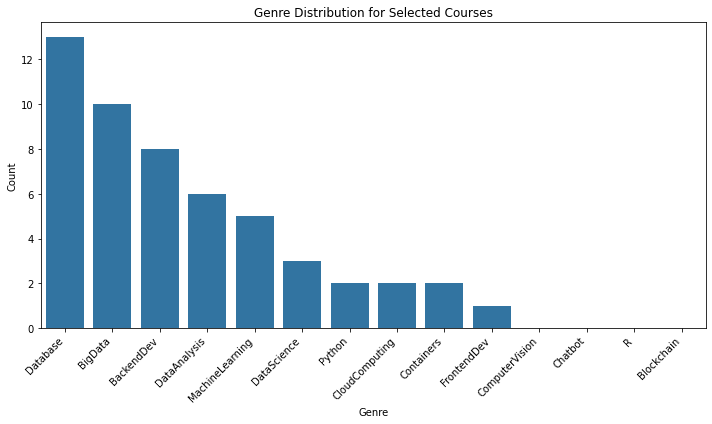

In [54]:
# Visualize genres of user's liked courses
liked_genres = plot_course_genres(user_liked_courses, courses_df, genre_columns)
print("Genres of courses the user liked:")
liked_genres

Genres of recommended courses:


,Genre,Count
1,Python,2
5,MachineLearning,2
7,DataScience,2
2,CloudComputing,1
0,Database,0
3,DataAnalysis,0
4,Containers,0
6,ComputerVision,0
8,BigData,0
9,Chatbot,0


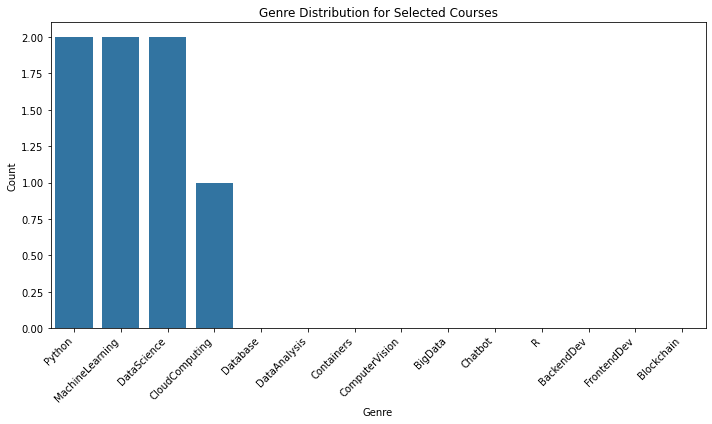

In [55]:
# Visualize genres of recommended courses
recommended_genres = plot_course_genres(user_recommendations['COURSE_ID'], courses_df, genre_columns)
print("Genres of recommended courses:")
recommended_genres

## Saving the Model

Let's save our recommendation model components for future use.

In [56]:
# Create directory if it doesn't exist
os.makedirs('model', exist_ok=True)

# Save the TF-IDF vectorizer
with open('model/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(enhanced_tfidf_vectorizer, f)

# Save the similarity matrix
enhanced_cosine_sim_df.to_pickle('model/similarity_matrix.pkl')

# Save the preprocessed course data
courses_df.to_pickle('model/preprocessed_courses.pkl')

## Visualizing Course Similarities with t-SNE

Let's create a visualization of how courses are related to each other in our feature space using t-SNE dimensionality reduction.

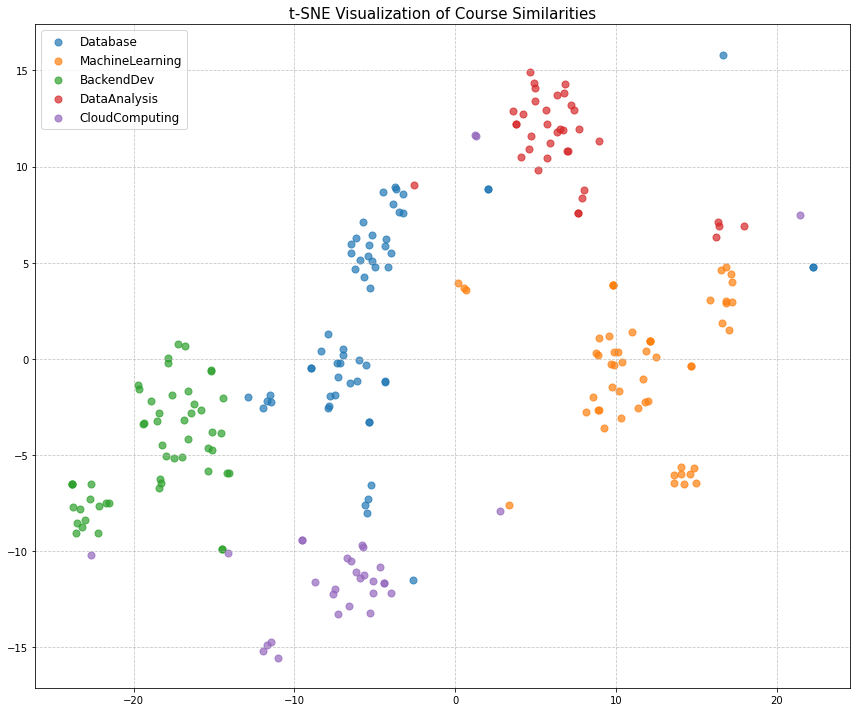

In [58]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Convert the sparse TF-IDF matrix to a dense array for t-SNE
# Note: For large datasets, you may want to reduce dimensionality first with TruncatedSVD
from sklearn.decomposition import TruncatedSVD

# First reduce dimensions with TruncatedSVD to make t-SNE faster and more stable
svd = TruncatedSVD(n_components=50, random_state=42)
svd_result = svd.fit_transform(enhanced_tfidf_matrix)

# Now apply t-SNE on the reduced data
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='random')
tsne_result = tsne.fit_transform(svd_result)

# Create a DataFrame with the t-SNE results
tsne_df = pd.DataFrame({
    'x': tsne_result[:, 0],
    'y': tsne_result[:, 1],
    'course_id': courses_df['COURSE_ID'],
    'title': courses_df['TITLE'],
    'genre_count': courses_df['genre_count']
})

# Find the dominant genre for each course
def get_dominant_genre(row):
    genre_vals = [row[genre] for genre in genre_columns]
    if sum(genre_vals) == 0:
        return 'None'
    max_idx = genre_vals.index(max(genre_vals))
    return genre_columns[max_idx]

courses_df['dominant_genre'] = courses_df.apply(get_dominant_genre, axis=1)
tsne_df['dominant_genre'] = courses_df['dominant_genre']

# Get the most common genres
top_genres = courses_df['dominant_genre'].value_counts().head(5).index.tolist()

# Filter to only show the top genres
plot_df = tsne_df[tsne_df['dominant_genre'].isin(top_genres)]

# Plot
plt.figure(figsize=(12, 10))
for i, genre in enumerate(top_genres):
    subset = plot_df[plot_df['dominant_genre'] == genre]
    plt.scatter(subset['x'], subset['y'], label=genre, alpha=0.7, s=50)

plt.title('t-SNE Visualization of Course Similarities', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Interactive Recommendations

Let's create a function to interactively explore recommendations for different courses.

In [59]:
def interactive_recommendations(course_title_query, similarity_matrix, courses_data, top_n=5):
    """
    Find courses matching a title query and display recommendations
    """
    # Find courses that match the query
    matching_courses = courses_data[courses_data['TITLE'].str.contains(course_title_query, case=False)]
    
    if len(matching_courses) == 0:
        print(f"No courses found matching '{course_title_query}'.")
        return
    
    print(f"Found {len(matching_courses)} matching courses:\n")
    
    # Display the matching courses
    for i, (_, course) in enumerate(matching_courses.iterrows()):
        print(f"{i+1}. {course['TITLE']} (ID: {course['COURSE_ID']})")
        print(f"   Genres: {[genre for genre in genre_columns if course[genre] == 1]}\n")
    
    # If multiple matches, ask which one to use
    if len(matching_courses) > 1:
        choice = input(f"\nEnter the number (1-{len(matching_courses)}) of the course to get recommendations for: ")
        try:
            choice_idx = int(choice) - 1
            if choice_idx < 0 or choice_idx >= len(matching_courses):
                print("Invalid selection. Using the first course.")
                choice_idx = 0
        except:
            print("Invalid input. Using the first course.")
            choice_idx = 0
    else:
        choice_idx = 0
    
    selected_course = matching_courses.iloc[choice_idx]
    print(f"\nGetting recommendations for: {selected_course['TITLE']}\n")
    
    # Get recommendations
    recommendations = get_course_recommendations(selected_course['COURSE_ID'], similarity_matrix, courses_data, top_n)
    
    # Display the recommendations
    print("Top Recommendations:")
    for i, (_, rec) in enumerate(recommendations.iterrows()):
        print(f"{i+1}. {rec['TITLE']} (Similarity: {rec['similarity_score']:.2f})")
        course_genres = [genre for genre in genre_columns if courses_data[courses_data['COURSE_ID'] == rec['COURSE_ID']][genre].values[0] == 1]
        print(f"   Genres: {course_genres}\n")
    
    return recommendations

In [60]:
# Test the interactive recommendations function
# Note: In Jupyter, you'll need to manually set the choice if prompted
sample_query = "python"  # Try with different queries like "data", "machine learning", etc.
interactive_recommendations(sample_query, enhanced_cosine_sim_df, courses_df)

Found 27 matching courses:

1. data science bootcamp with python for university professors  advance (ID: DX0108EN)
   Genres: ['Python', 'DataScience']

2. create a cryptocurrency trading algorithm in python (ID: GPXX0PICEN)
   Genres: ['Python']

3. data science bootcamp with python (ID: TMP107)
   Genres: ['Python', 'DataScience']

4. launch an ai hotdog detector as a serverless python app (ID: GPXX0YMEEN)
   Genres: ['Python', 'MachineLearning', 'ComputerVision']

5. deploy a web server using python and ibm cloud engine (ID: GPXX04V3EN)
   Genres: ['Python', 'CloudComputing', 'BackendDev']

6. data science bootcamp with python for university professors (ID: DX0107EN)
   Genres: ['DataScience']

7. machine learning with python (ID: ML0101EN)
   Genres: ['Python', 'MachineLearning', 'DataScience']

8. machine learning with python (ID: ML0101ENv3)
   Genres: ['Python', 'MachineLearning']

9. data analysis with python (ID: DA0101EN)
   Genres: ['Python', 'DataAnalysis']

10. train a hot


Enter the number (1-27) of the course to get recommendations for:  5



Getting recommendations for: deploy a web server using python and ibm cloud engine

Top Recommendations:
1. using databases with python (Similarity: 0.58)
   Genres: ['Python']

2. python basics (Similarity: 0.58)
   Genres: ['Python']

3. introduction to python programming (Similarity: 0.55)
   Genres: ['Python']

4. data analysis using python (Similarity: 0.52)
   Genres: ['Python', 'DataAnalysis']

5. data analysis using python (Similarity: 0.52)
   Genres: ['Python', 'DataAnalysis']



,COURSE_ID,TITLE,genre_count,similarity_score
221,excourse08,using databases with python,1,0.583669
230,excourse17,python basics,1,0.581101
232,excourse19,introduction to python programming,1,0.550767
236,excourse23,data analysis using python,2,0.521362
249,excourse36,data analysis using python,2,0.521362


## Advanced Evaluation Metrics

Let's implement more sophisticated evaluation metrics for our recommendation system.

In [ ]:
def evaluate_recommendation_diversity(recommendations_df, courses_data, genre_cols):
    """
    Calculate the diversity of recommendations based on genre coverage
    """
    # Get the genre profiles for all recommended courses
    genre_profiles = []
    for _, rec in recommendations_df.iterrows():
        course = courses_data[courses_data['COURSE_ID'] == rec['COURSE_ID']].iloc[0]
        genre_profile = [course[genre] for genre in genre_cols]
        genre_profiles.append(genre_profile)
    
    # Convert to array
    genre_profiles = np.array(genre_profiles)
    
    # Calculate diversity as the number of unique genres covered
    genres_covered = np.sum(np.any(genre_profiles == 1, axis=0))
    diversity_ratio = genres_covered / len(genre_cols)
    
    # Calculate average pairwise similarity (lower means more diverse)
    if len(genre_profiles) > 1:
        pairwise_sims = []
        for i in range(len(genre_profiles)):
            for j in range(i+1, len(genre_profiles)):
                # Calculate Jaccard similarity
                intersection = np.sum((genre_profiles[i] == 1) & (genre_profiles[j] == 1))
                union = np.sum((genre_profiles[i] == 1) | (genre_profiles[j] == 1))
                if union > 0:
                    pairwise_sims.append(intersection / union)
                else:
                    pairwise_sims.append(0)
        avg_similarity = np.mean(pairwise_sims) if pairwise_sims else 0
    else:
        avg_similarity = 1.0  # Only one course, so similarity is perfect
    
    return {
        'genres_covered': int(genres_covered),
        'total_genres': len(genre_cols),
        'diversity_ratio': diversity_ratio,
        'avg_pairwise_similarity': avg_similarity,
        'diversity_score': 1 - avg_similarity
    }

In [ ]:
# Test the diversity evaluation
diversity_metrics = evaluate_recommendation_diversity(recommendations, courses_df, genre_columns)
enhanced_diversity_metrics = evaluate_recommendation_diversity(enhanced_recommendations, courses_df, genre_columns)

print("Basic Recommendation Diversity:")
for metric, value in diversity_metrics.items():
    print(f"- {metric}: {value:.2f}" if isinstance(value, float) else f"- {metric}: {value}")

print("\nEnhanced Recommendation Diversity:")
for metric, value in enhanced_diversity_metrics.items():
    print(f"- {metric}: {value:.2f}" if isinstance(value, float) else f"- {metric}: {value}")

## Implementing a Cold Start Solution

Let's address the cold start problem by recommending courses based on genre preferences.

In [ ]:
def recommend_by_genres(selected_genres, courses_data, genre_cols, top_n=5):
    """
    Recommend courses based on selected genres
    """
    # Validate selected genres
    valid_genres = [g for g in selected_genres if g in genre_cols]
    if not valid_genres:
        print(f"No valid genres selected. Available genres: {list(genre_cols)}")
        return pd.DataFrame()
    
    # Create a score for each course based on how many selected genres it matches
    scores = []
    for _, course in courses_data.iterrows():
        # Count how many selected genres this course matches
        matches = sum(course[genre] == 1 for genre in valid_genres)
        # Calculate a weighted score (matches / total genres in the course)
        total_genres = sum(course[genre] == 1 for genre in genre_cols)
        score = matches / total_genres if total_genres > 0 else 0
        # Weight by the number of matches as well to prefer courses with more matches
        weighted_score = score * matches if matches > 0 else 0
        
        scores.append({
            'course_id': course['COURSE_ID'],
            'title': course['TITLE'],
            'genre_count': course['genre_count'],
            'matches': matches,
            'score': weighted_score
        })
    
    # Convert to DataFrame and sort by score
    scores_df = pd.DataFrame(scores)
    
    # Filter to courses with at least one match and sort
    matching_courses = scores_df[scores_df['matches'] > 0].sort_values('score', ascending=False)
    
    if len(matching_courses) == 0:
        print(f"No courses found matching the selected genres: {valid_genres}")
        return pd.DataFrame()
    
    return matching_courses.head(top_n)

In [ ]:
# Test the genre-based recommendations
selected_genres = ['Python', 'MachineLearning']  # Try different combinations
genre_recommendations = recommend_by_genres(selected_genres, courses_df, genre_columns)

print(f"Top recommendations for genres {selected_genres}:\n")
for i, (_, rec) in enumerate(genre_recommendations.iterrows()):
    print(f"{i+1}. {rec['title']} (Score: {rec['score']:.2f}, Matches: {rec['matches']})")
    course_genres = [genre for genre in genre_columns if courses_df[courses_df['COURSE_ID'] == rec['course_id']][genre].values[0] == 1]
    print(f"   All Genres: {course_genres}\n")

## Creating a Recommendation Pipeline

Let's combine our different recommendation approaches into a complete pipeline.

In [ ]:
def recommendation_pipeline(user_id=None, course_id=None, genres=None, similarity_matrix=None, 
                           courses_data=None, ratings_data=None, genre_cols=None, top_n=5):
    """
    Complete recommendation pipeline that selects the appropriate strategy based on available information
    """
    # Initialize variables
    if similarity_matrix is None:
        similarity_matrix = enhanced_cosine_sim_df
    if courses_data is None:
        courses_data = courses_df
    if ratings_data is None:
        ratings_data = ratings_df
    if genre_cols is None:
        genre_cols = genre_columns
    
    # Determine which recommendation strategy to use
    if user_id is not None:
        # Check if the user has ratings
        user_ratings = ratings_data[ratings_data['user'] == user_id]
        if len(user_ratings) > 0:
            print(f"\nGenerating recommendations for user {user_id} based on {len(user_ratings)} ratings...\n")
            recommendations = get_user_recommendations(user_id, ratings_data, similarity_matrix, courses_data, top_n)
            if len(recommendations) > 0:
                return recommendations, "user_history"
            else:
                print("No user-based recommendations found. Falling back to content-based...")
    
    if course_id is not None:
        # Check if the course exists
        if course_id in courses_data['COURSE_ID'].values:
            print(f"\nGenerating recommendations similar to course {course_id}...\n")
            recommendations = get_course_recommendations(course_id, similarity_matrix, courses_data, top_n)
            return recommendations, "content_based"
    
    if genres is not None and len(genres) > 0:
        print(f"\nGenerating recommendations based on genre preferences: {genres}...\n")
        recommendations = recommend_by_genres(genres, courses_data, genre_cols, top_n)
        if len(recommendations) > 0:
            return recommendations, "genre_based"
    
    # If all else fails, recommend popular courses
    print("\nNo specific criteria provided. Recommending popular courses...\n")
    
    # Calculate course popularity
    course_ratings = ratings_data.groupby('item')['rating'].agg(['mean', 'count'])
    # Filter to courses with at least 10 ratings
    popular_courses = course_ratings[course_ratings['count'] >= 10].sort_values('mean', ascending=False)
    # Get course details
    popular_recommendations = courses_data[courses_data['COURSE_ID'].isin(popular_courses.head(top_n).index)].copy()
    
    if len(popular_recommendations) > 0:
        # Add the average rating and count
        popular_recommendations['avg_rating'] = popular_recommendations['COURSE_ID'].apply(
            lambda x: popular_courses.loc[x, 'mean'] if x in popular_courses.index else None)
        popular_recommendations['rating_count'] = popular_recommendations['COURSE_ID'].apply(
            lambda x: popular_courses.loc[x, 'count'] if x in popular_courses.index else None)
        
        # Sort by average rating
        popular_recommendations = popular_recommendations.sort_values('avg_rating', ascending=False)
        return popular_recommendations[['COURSE_ID', 'TITLE', 'genre_count', 'avg_rating', 'rating_count']], "popularity"
    
    # If no popular courses found (unlikely), return the first N courses
    return courses_data.head(top_n), "fallback"

In [ ]:
# Test the recommendation pipeline with different scenarios

# Scenario 1: Recommendations for a specific user
user_recs, strategy = recommendation_pipeline(user_id=test_user_id)
print(f"Strategy used: {strategy}")
print("User recommendations:")
print(user_recs)

# Scenario 2: Recommendations for a specific course
course_recs, strategy = recommendation_pipeline(course_id=test_course_id)
print(f"\nStrategy used: {strategy}")
print("Course-based recommendations:")
print(course_recs)

# Scenario 3: Recommendations based on genres
genre_recs, strategy = recommendation_pipeline(genres=['Python', 'DataScience'])
print(f"\nStrategy used: {strategy}")
print("Genre-based recommendations:")
print(genre_recs)

# Scenario 4: Fallback to popular courses
popular_recs, strategy = recommendation_pipeline()
print(f"\nStrategy used: {strategy}")
print("Popular course recommendations:")
print(popular_recs)

## Conclusion

In this notebook, we've built a comprehensive content-based course recommendation system that:

1. Analyzes course genre data to identify similarities between courses
2. Generates numerical representations of course content using TF-IDF
3. Calculates course similarity using cosine similarity
4. Provides content-based course recommendations
5. Enhances recommendations by incorporating course titles
6. Extends to user-based recommendations based on rating history
7. Evaluates recommendation quality using genre overlap metrics
8. Visualizes course similarities using t-SNE dimensionality reduction
9. Implements advanced diversity metrics for recommendation evaluation
10. Addresses the cold start problem with genre-based recommendations
11. Creates a complete recommendation pipeline with multiple strategies

Future improvements could include:
- Implementing collaborative filtering approaches
- Combining content-based and collaborative filtering into a hybrid system
- Incorporating course popularity and recency data
- Building a user interface for the recommendation system
- Adding more sophisticated evaluation metrics and A/B testing capabilities
- Implementing deep learning-based recommendation approaches